<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/02a_MNIST_KDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# ==========================================
# 1. SETUP E INFRAESTRUCTURA
# ==========================================
import os
import sys
from google.colab import drive

# 1.1. Montar Drive para acceder al Token
drive.mount('/content/drive', force_remount=True)
CARPETA_DRIVE = '/content/drive/MyDrive/01.Maestria/MLOps'
if CARPETA_DRIVE not in sys.path: sys.path.append(CARPETA_DRIVE)

# 1.2. Inicializar Proyecto desde GitHub
import setup_env
setup_env.init_project(drive_token_path=f"{CARPETA_DRIVE}/github_token.txt")

# 1.3. Configurar Directorio de Trabajo y Path de Python
REPO_PATH = "/content/Analisis-KDM-PNC"
os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)


Mounted at /content/drive
🚀 Iniciando configuración del entorno MLOps...
[*] El repositorio Analisis-KDM-PNC ya existe. Haciendo 'git pull' para actualizar...
[*] Directorio de trabajo establecido en: /content/Analisis-KDM-PNC
[*] Credenciales de Git configuradas.

[✅ ÉXITO] Entorno listo. Ya puedes importar módulos de Analisis-KDM-PNC.


In [26]:

# 1.4. Instalación de librerías necesarias para el experimento
!pip install -q scikeras pyyaml
# Forzar versiones compatibles para evitar el error de __sklearn_tags__
!pip install -q "scikit-learn<1.6.0" scikeras pyyaml


In [27]:

print(f"\n[✅] Ubicado en: {os.getcwd()}")
print("[✅] Entorno listo e instalado.")


[✅] Ubicado en: /content/Analisis-KDM-PNC
[✅] Entorno listo e instalado.


In [28]:
# ==========================================
# 2. CARGA DE CONFIGURACIÓN Y DATOS
# ==========================================
from src.utils.config_parser import load_config
from src.data.dataset_loaders import get_pipeline
from src.models import build_kdm

# Cargar la configuración que editaste manualmente
config = load_config('mnist', 'kdm')

# Cargar datos a través del pipeline
pipeline = get_pipeline('mnist', batch_size=32)
X_train, y_train, X_test, y_test = pipeline.get_kdm_data()

print(f"[✅] Datos cargados. Entrenamiento configurado para {config['entrenamiento_final']['epochs']} épocas.")

[✅] Datos cargados. Entrenamiento configurado para 10 épocas.


In [29]:
X_train.shape

(60000, 784)

In [32]:
# ==========================================
# 3. EXPERIMENTACIÓN: GRID SEARCH (KDM SPECIFIC)
# ==========================================
import pandas as pd
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from src.utils.config_parser import load_config
from src.data.dataset_loaders import get_pipeline
from src.models import build_kdm

# 1. Cargar Configuración
config = load_config('mnist', 'kdm')

def create_model(n_comp=256, encoded_size=64, lr=0.001, sigma=0.5): # <--- sigma aquí
    local_conf = {
        'dataset': config.get('dataset', 'mnist'),
        'n_comp': int(n_comp),
        'encoded_size': int(encoded_size),
        'arquitectura': {
            'input_dim': config['arquitectura']['input_dim'],
            'n_classes': config['arquitectura']['n_classes'],
            'sigma': float(sigma), # <--- sigma inyectado desde el grid
            'sigma_trainable': config['arquitectura']['sigma_trainable']
        },
        'entrenamiento': {'learning_rate': float(lr)}
    }
    return build_kdm(local_conf)

# 2. Wrapper de SciKeras (Añadimos sigma al constructor)
model_wrapper = KerasClassifier(
    model=create_model,
    epochs=5,
    verbose=0,
    n_comp=256,
    encoded_size=64,
    lr=0.001,
    sigma=0.5 # <--- Valor por defecto para el wrapper
)

# 3. Configurar la búsqueda
print("🚀 Iniciando GridSearch (Esto tardará más debido a Sigma)...")
grid = GridSearchCV(
    estimator=model_wrapper,
    param_grid=config['grid_search']['param_grid'],
    cv=config['grid_search']['cv_folds'],
    scoring='accuracy',
    verbose=1
)

# 4. Ejecutar (Seguimos con muestra de 15k para no morir en el intento)
grid_result = grid.fit(X_train[:25000], y_train[:25000])

print(f"\n🏆 GANADOR CON SIGMA: {grid_result.best_params_}")

# 6. Resultados
print(f"\n🏆 MEJOR KDM ENCONTRADO: {grid_result.best_params_}")
cv_results = pd.DataFrame(grid_result.cv_results_).sort_values('rank_test_score')
display(cv_results[['params', 'mean_test_score', 'rank_test_score']].head())

🚀 Iniciando GridSearch (Esto tardará más debido a Sigma)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyendo KDM (TensorFlow) para MNIST...
[*] Construyend

,params,mean_test_score,rank_test_score
5,"{'encoded_size': 64, 'lr': 0.001, 'n_comp': 51...",0.95868,1
17,"{'encoded_size': 128, 'lr': 0.001, 'n_comp': 5...",0.95740,2
0,"{'encoded_size': 64, 'lr': 0.001, 'n_comp': 25...",0.95716,3
2,"{'encoded_size': 64, 'lr': 0.001, 'n_comp': 25...",0.95704,4
1,"{'encoded_size': 64, 'lr': 0.001, 'n_comp': 25...",0.95672,5


In [34]:
# ==========================================
# 4. ENTRENAMIENTO FINAL Y PERSISTENCIA (KDM)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix

# 4.1. Re-entrenar con los mejores parámetros del KDM
print("\n🔥 Entrenando modelo definitivo con parámetros óptimos...")
best_params = grid_result.best_params_

# USAMOS LAS LLAVES REALES: n_comp, encoded_size y lr
modelo_final = create_model(
    n_comp=best_params['n_comp'],
    encoded_size=best_params['encoded_size'],
    lr=best_params['lr']
)

history = modelo_final.fit(
    X_train, y_train,
    epochs=config['entrenamiento_final']['epochs'],
    batch_size=int(best_params.get('batch_size', 64)), # Por si acaso no estaba en el grid
    validation_split=0.2,
    verbose=1
)


🔥 Entrenando modelo definitivo con parámetros óptimos...
[*] Construyendo KDM (TensorFlow) para MNIST...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9038 - loss: 0.3421 - val_accuracy: 0.9464 - val_loss: 0.1920
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9531 - loss: 0.1630 - val_accuracy: 0.9589 - val_loss: 0.1440
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9664 - loss: 0.1150 - val_accuracy: 0.9623 - val_loss: 0.1239
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9748 - loss: 0.0875 - val_accuracy: 0.9644 - val_loss: 0.1169
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9802 - loss: 0.0694 - val_accuracy: 0.9693 - val_loss: 0.1037
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9838 - loss: 0.0561 - val_accuracy: 0.9696 - val_loss: 0.1011
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9867 - loss: 0.0451 - val_accuracy: 0.9723 - val_loss: 0.0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[✅] Imagen guardada correctamente en resultados/mnist/graficas/resultado_final.png


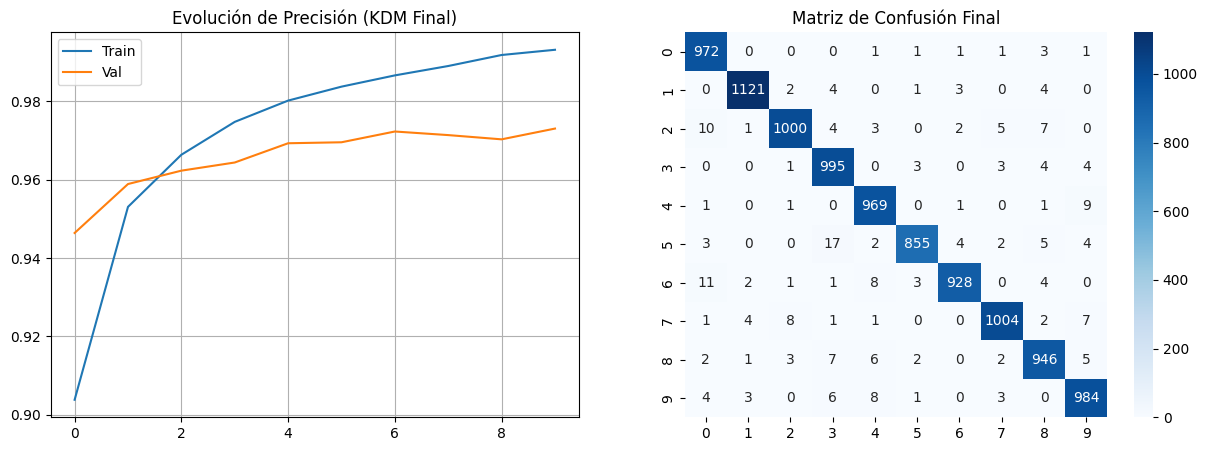


[🏁] ¡Todo guardado! Verifica ahora con !ls resultados/mnist/metricas


In [35]:


# ==========================================
# 4.2. Evaluación y Gráficas (CORREGIDO PARA GUARDADO)
# ==========================================
y_pred = np.argmax(modelo_final.predict(X_test), axis=1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfica 1: Curvas de Aprendizaje ---
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Evolución de Precisión (KDM Final)')
ax[0].legend()
ax[0].grid(True) # Un buen toque MLOps

# --- Gráfica 2: Matriz de Confusión ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Matriz de Confusión Final')



# =========================================================

# 4.3. PERSISTENCIA: Aquí es donde aseguramos que NO esté vacía la carpeta
# Forzamos la ruta relativa al repo para que Git lo vea
ruta_base = "resultados/mnist"
os.makedirs(f"{ruta_base}/modelos", exist_ok=True)
os.makedirs(f"{ruta_base}/metricas", exist_ok=True)
os.makedirs(f"{ruta_base}/graficas", exist_ok=True)

# Guardar Pesos
modelo_final.save_weights(f"{ruta_base}/modelos/kdm_best_model.weights.h5")

# Guardar Reporte CSV
report = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report).transpose().to_csv(f"{ruta_base}/metricas/mejor_kdm_report.csv")

# Guardar el historial del GridSearch que obtuvimos en la Celda 3
cv_results = pd.DataFrame(grid_result.cv_results_)
cv_results.to_csv(f"{ruta_base}/metricas/gridsearch_history.csv")


# Guardamos la figura COMPLETA (fig)
fig.savefig(f"{ruta_base}/graficas/resultado_final.png", dpi=300, bbox_inches='tight')
print(f"[✅] Imagen guardada correctamente en {ruta_base}/graficas/resultado_final.png")

# Ahora sí, podemos mostrarla en el notebook
plt.show()
print(f"\n[🏁] ¡Todo guardado! Verifica ahora con !ls {ruta_base}/metricas")

In [36]:
# Borra todos los __pycache__ y archivos .pyc recursivamente
!find . -name "*.pyc" -delete
!find . -name "__pycache__" -delete

In [37]:
!git config --global user.email "bspd1007@gmail.com"
!git config --global user.name "Steven Peña"

In [38]:
gitignore_content = """
__pycache__/
*.pyc
data/
.ipynb_checkpoints/
*.weights.h5
*.h5
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content)

print("[✅] .gitignore creado.")

[✅] .gitignore creado.


In [39]:
# 1. Añadimos el nuevo .gitignore
!git add .gitignore

# 2. Añadimos la configuración que usamos para el experimento
!git add configs/mnist/kdm.yaml

# 3. Añadimos solo las métricas y gráficas (archivos ligeros)
!git add resultados/mnist/metricas/
!git add resultados/mnist/graficas/

# 4. Hacemos el commit
!git commit -m "docs: resultados del experimento KDM MNIST y config de GridSearch"

# 5. Push al repositorio
!git push origin main

[main 56e89a3] docs: resultados del experimento KDM MNIST y config de GridSearch
 3 files changed, 39 insertions(+), 23 deletions(-)
 rewrite resultados/mnist/graficas/resultado_final.png (96%)
 rewrite resultados/mnist/metricas/gridsearch_history.csv (96%)
 rewrite resultados/mnist/metricas/mejor_kdm_report.csv (94%)
Enumerating objects: 17, done.
Counting objects: 100% (17/17), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 195.05 KiB | 8.13 MiB/s, done.
Total 9 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Steven10P/Analisis-KDM-PNC.git
   b70fcc9..56e89a3  main -> main
